In [ ]:
# __ROOTBOOT__ ensure project root on sys.path (auto-added; safe to keep)
import os as _os, sys as _sys
_r = _os.path.abspath('')
while _r != _os.path.dirname(_r) and not _os.path.exists(_os.path.join(_r, '.project_root')):
    _r = _os.path.dirname(_r)
if _os.path.exists(_os.path.join(_r, '.project_root')) and _r not in _sys.path:
    _sys.path.insert(0, _r)


# Regime Factor Rotation — Signal Research

**Instruments:** 5 MSCI/Pacer factor ETFs
- **SIZE** (iShares MSCI USA Size)        — SMB proxy, inception Apr 2013
- **VLUE** (iShares MSCI USA Value)       — HML proxy, inception Apr 2013
- **QUAL** (iShares MSCI USA Quality)     — RMW proxy, inception Jul 2013
- **COWZ** (Pacer US Cash Cows 100)       — CMA approximation, inception Dec 2016 (LIMITS START DATE)
- **MTUM** (iShares MSCI USA Momentum)    — Mom proxy, inception Apr 2013

**Signal:** Monthly GMM regime classification using 32 FRED-MD macro features
(via P3's walk-forward logic). For the current regime, rank factors by historical
regime-conditioned average returns, hold top-K factor ETFs equal-weight for one month.

**Entry:** Next trading day's open after month-end rebalance.
**Exit:** Close of next month-end rebalance when factor drops out of top-K.
**Direction:** Long-only.
**Architecture:** Basket (single capital pool, concurrent positions, MTM daily).

**This notebook:**
1. Signal engine: GMM walk-forward + regime-conditioned factor ranking (P3 logic embedded)
2. Grid search: `top_n × n_regimes` (PCA=10, cov='full', refit=24 fixed from P3)
3. Significance tests on MTM daily returns
4. Per-factor breakdown
5. Save standardized trades

**Sizing & implementation comparison** -> see `Regime_Factor_Rotation_Implementation.ipynb`

**Walk-forward handling:** GMM trains on full macro history from 1984 onward (P3's original
setup — gives regime classifier rich training data). Tradeable universe is limited to ETF
availability, so actual trades only execute from **2017-01-01** onward (post COWZ inception
+ cushion). Factor-to-regime lookup table uses full factor return history.

**Academic backing:** Based on P3 (GMM regime factor allocation) which achieved
Sharpe 0.391 on synthetic Fama-French factors (p=0.037, t=2.10). This notebook tests
whether that edge survives implementation via real factor ETFs, where tracking error,
CMA approximation via COWZ, and shorter 2017+ walk-forward are expected to reduce the result.


## 1. Setup

In [1]:
import sys
sys.path.insert(0, "../..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from itertools import product
from alpaca.data.timeframe import TimeFrame, TimeFrameUnit

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture

import pandas_datareader.data as web

from _shared.loaders_data import fetch_historical_data
from _shared.fees import calculate_fees, calculate_fees_pct
from _shared.implementations import build_basket_equity
from _shared.significance import full_significance_report, print_significance_report

import warnings
warnings.filterwarnings('ignore')

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)


In [2]:
# =============================================================================
# CONFIGURATION
# =============================================================================

# Factor ETFs (SIZE=SMB, VLUE=HML, QUAL=RMW, COWZ=CMA approx, MTUM=Mom)
ETFS = ["SIZE", "VLUE", "QUAL", "COWZ", "MTUM"]
FACTOR_NAMES = ["SMB", "HML", "RMW", "CMA", "Mom"]
FACTOR_TO_ETF = dict(zip(FACTOR_NAMES, ETFS))
ETF_TO_FACTOR = dict(zip(ETFS, FACTOR_NAMES))

# Walk-forward windows
MACRO_START = "1984-01-01"          # GMM training data starts here
TRADE_START = "2016-01-01"          # First trade after COWZ live + cushion
TRADE_END   = "2026-04-01"

# Path to P1's output (copy these two files into ./data/ if not already there)
DATA_DIR = "./data"

STARTING_CAPITAL = 100_000
LEVERAGE         = 1
STRATEGY_NAME    = "Regime Factor Rotation"
SAVE_NAME        = "regime_factor_rotation"
BET_SIZE         = 0.85

# GMM hyperparameters (fixed from P3's best config)
GMM_PCA_COMPONENTS = 10
GMM_COV_TYPE       = "full"
GMM_REFIT_EVERY    = 24             # months
GMM_INIT_TRAIN_PCT = 0.50           # 50% of macro history for initial training


## 2. Data: Macro Panel + Factor Returns + ETF Prices

Three data sources:
1. **Macro panel** — 32 FRED-MD features from P1. GMM trains on this (1984+).
2. **Fama-French factor returns** — monthly factor returns (SMB, HML, RMW, CMA, Mom)
   from Ken French's library. Used to build the regime → factor-ranking lookup table.
3. **Factor ETF prices** — daily OHLC for SIZE/VLUE/QUAL/COWZ/MTUM. Used for actual
   entry/exit prices in backtested trades.


In [3]:
# ── 1. Macro panel from P1 ──
monthly_macro   = pd.read_csv(f"{DATA_DIR}/monthly_panel_transformed.csv",
                                index_col=0, parse_dates=True)
quarterly_macro = pd.read_csv(f"{DATA_DIR}/quarterly_panel_transformed.csv",
                                index_col=0, parse_dates=True)

quarterly_ffill = quarterly_macro.resample("MS").ffill()
macro_panel = pd.concat([monthly_macro, quarterly_ffill], axis=1).ffill().bfill().fillna(0)
macro_panel = macro_panel.dropna(axis=1, how="all")
macro_panel = macro_panel[macro_panel.index >= MACRO_START]
print(f"Macro panel: {macro_panel.shape}, range {macro_panel.index.min().date()} -> {macro_panel.index.max().date()}")

# ── 2. Fama-French factor returns (monthly) ──
ff5 = web.DataReader("F-F_Research_Data_5_Factors_2x3", "famafrench", start="1963-01-01")
mom = web.DataReader("F-F_Momentum_Factor", "famafrench", start="1963-01-01")
factors_all = ff5[0].join(mom[0]) / 100
factors_all.index = factors_all.index.to_timestamp()
factor_returns = factors_all[FACTOR_NAMES].copy()

# Align macro and factor returns
common_start = max(macro_panel.index.min(), factor_returns.index.min())
common_end   = min(macro_panel.index.max(), factor_returns.index.max())
common_idx = macro_panel[common_start:common_end].index.intersection(
    factor_returns[common_start:common_end].index)
macro_aligned   = macro_panel.loc[common_idx]
factors_aligned = factor_returns.loc[common_idx]
print(f"Aligned: macro {macro_aligned.shape}, factors {factors_aligned.shape}")
print(f"Range: {common_idx.min().date()} -> {common_idx.max().date()}")

# ── 3. Factor ETF daily prices ──
data_dict = fetch_historical_data(
    ETFS, TimeFrame(1, TimeFrameUnit.Day), TRADE_START, TRADE_END)

all_data = {}
for sym in ETFS:
    if sym not in data_dict:
        print(f"  {sym}: NOT AVAILABLE -- skipping")
        continue
    d = data_dict[sym].copy()
    if d.index.tz is None:
        d.index = d.index.tz_localize("UTC").tz_convert("US/Eastern")
    else:
        d.index = d.index.tz_convert("US/Eastern")
    d = d.reset_index()
    d["date"] = d["timestamp"].dt.date
    d = d.groupby("date").last().reset_index()
    d["date"] = pd.to_datetime(d["date"])
    d = d[["date", "open", "high", "low", "close", "volume"]].sort_values("date").reset_index(drop=True)
    all_data[sym] = d
    print(f"{sym}: {len(d):,} bars, {d['date'].iloc[0].date()} -> {d['date'].iloc[-1].date()}")

AVAILABLE_ETFS = list(all_data.keys())
AVAILABLE_FACTORS = [ETF_TO_FACTOR[e] for e in AVAILABLE_ETFS]
print(f"\n{len(AVAILABLE_ETFS)} ETFs available: {AVAILABLE_ETFS}")
print(f"  mapping to factors: {AVAILABLE_FACTORS}")


Macro panel: (502, 32), range 1984-04-01 -> 2026-01-01
Aligned: macro (502, 32), factors (502, 5)
Range: 1984-04-01 -> 2026-01-01
Fetching SIZE...
  2,575 bars
Fetching VLUE...
  2,575 bars
Fetching QUAL...
  2,575 bars
Fetching COWZ...
  2,332 bars
Fetching MTUM...
  2,575 bars
SIZE: 2,575 bars, 2016-01-04 -> 2026-03-31
VLUE: 2,575 bars, 2016-01-04 -> 2026-03-31
QUAL: 2,575 bars, 2016-01-04 -> 2026-03-31
COWZ: 2,332 bars, 2016-12-19 -> 2026-03-31
MTUM: 2,575 bars, 2016-01-04 -> 2026-03-31

5 ETFs available: ['SIZE', 'VLUE', 'QUAL', 'COWZ', 'MTUM']
  mapping to factors: ['SMB', 'HML', 'RMW', 'CMA', 'Mom']


## 3. Signal Engine

Embeds P3's GMM walk-forward regime-allocation logic directly. At each monthly
rebalance date:

1. **Train/refit GMM** on all macro history up to that date (refit every 24 months).
2. **Classify current regime** by applying fit PCA + GMM to the latest macro row.
3. **Reclassify all past months** with the current model (ensures regime labels are
   internally consistent — P3's approach).
4. **Rank factors** by their average return during past months that were in the same
   regime as today. Rank-based weights are then intersected with tradeable ETFs.
5. **Select top-K factors** (from tradeable ones). Those are the new positions.
6. **Generate trade entries/exits** based on rotation: any ETF in top-K this month
   AND next month continues (no round-trip), any dropping out closes.

Trades emitted: one per contiguous period each ETF is held.


In [4]:
def compute_regime_weights(factor_rets_hist, regime_hist, current_regime, n_factors):
    """P3's rank-based regime weighting — copied exactly."""
    mask = regime_hist == current_regime
    if mask.sum() < 6:
        return np.ones(n_factors) / n_factors
    regime_avg = factor_rets_hist[mask].mean()
    ranks = regime_avg.rank(ascending=True)
    weights = ranks / ranks.sum()
    weights = np.maximum(weights.values, 0.05)
    return weights / weights.sum()


def generate_signals(all_data, macro_aligned, factors_aligned,
                      factor_names, etfs, factor_to_etf,
                      top_n, n_regimes,
                      n_pca=GMM_PCA_COMPONENTS, cov_type=GMM_COV_TYPE,
                      refit_every=GMM_REFIT_EVERY,
                      init_train_pct=GMM_INIT_TRAIN_PCT,
                      trade_start=TRADE_START):
    """
    Generate raw factor-rotation trades -- signal only, no sizing.

    Runs P3's GMM walk-forward regime classification + factor ranking,
    but restricts actual trading to the subset of factors with live ETFs
    and to dates >= trade_start.

    Returns DataFrame with standardized columns:
        entry_time, exit_time, direction, instrument, entry_price,
        exit_price, pct_return_gross, exit_reason, stop_price
    """
    N = len(macro_aligned)
    init_train = int(N * init_train_pct)
    n_factors = len(factor_names)
    trade_start_ts = pd.Timestamp(trade_start)

    # Build combined close+open price frame per ETF
    # Index = daily trading dates, columns = per-ETF close/open
    price_dfs = {}
    for sym, df in all_data.items():
        price_dfs[sym] = df.set_index("date")[["open", "close"]]

    # Find month-end indexes in macro (these are rebalance dates)
    macro_dates = macro_aligned.index
    # For each month-end macro date, find the NEXT trading day's open for entries
    # (P3 uses the macro date itself; we need actual market dates for trade prices)
    all_trading_dates = sorted(set().union(*[df.index for df in price_dfs.values()]))
    trading_idx = pd.DatetimeIndex(all_trading_dates)

    trades = []
    held = {}  # {etf_sym: {"entry_time":, "entry_price":, "factor":}}
    last_refit = -999
    gmm_model = None
    pca_model = None
    scaler_model = None

    for t in range(init_train, N):
        rebal_date = macro_dates[t]

        # ── 1. Refit GMM if needed ──
        if t - last_refit >= refit_every or t == init_train:
            scaler_model = StandardScaler()
            X_scaled = scaler_model.fit_transform(macro_aligned.iloc[:t])
            n_pca_safe = min(n_pca, X_scaled.shape[1], X_scaled.shape[0])
            pca_model = PCA(n_components=n_pca_safe)
            X_pca = pca_model.fit_transform(X_scaled)
            gmm_model = GaussianMixture(
                n_components=n_regimes, covariance_type=cov_type,
                n_init=10, random_state=42)
            gmm_model.fit(X_pca)
            last_refit = t

        # ── 2. Classify current regime ──
        x_now = pca_model.transform(scaler_model.transform(macro_aligned.iloc[[t]]))
        regime = gmm_model.predict(x_now)[0]

        # ── 3. Reclassify all past months (internally consistent, per P3) ──
        past_regimes = pd.Series(
            gmm_model.predict(
                pca_model.transform(scaler_model.transform(macro_aligned.iloc[:t]))),
            index=macro_aligned.index[:t])
        past_factors = factors_aligned.iloc[:t]
        common = past_factors.index.intersection(past_regimes.index)

        # ── 4. Full 5-factor weights from P3 logic ──
        w_full = compute_regime_weights(
            past_factors.loc[common], past_regimes.loc[common], regime, n_factors)

        # ── 5. Filter to tradeable factors (those with ETFs) and pick top-K ──
        tradeable_factors = [f for f in factor_names if f in factor_to_etf
                              and factor_to_etf[f] in all_data]
        tradeable_weights = {f: w_full[i] for i, f in enumerate(factor_names)
                              if f in tradeable_factors}
        # Sort by weight descending, take top_n
        ranked_factors = sorted(tradeable_weights.items(), key=lambda x: x[1], reverse=True)
        new_top_factors = [f for f, _ in ranked_factors[:top_n]]
        new_top_etfs = [factor_to_etf[f] for f in new_top_factors]

        # ── 6. Only start generating trades after trade_start ──
        if rebal_date < trade_start_ts:
            continue

        # Find the next trading day's prices for this rebalance
        next_td_mask = trading_idx > rebal_date
        if not next_td_mask.any():
            continue
        next_td = trading_idx[next_td_mask][0]

        # Close ETFs rotating OUT (exit at next trading day's open -- proxy for close of
        # rebalance day; but P3 logic is to exit at rebalance close. Using open of next
        # trading day keeps us consistent with a "next-day-open" execution rule).
        for etf in list(held.keys()):
            if etf not in new_top_etfs:
                info = held[etf]
                # Exit price = next trading day's open (same rule used for entries)
                if etf in price_dfs and next_td in price_dfs[etf].index:
                    exit_price = price_dfs[etf].loc[next_td, "open"]
                else:
                    continue
                pct_return_gross = (exit_price - info["entry_price"]) / info["entry_price"]
                trades.append({
                    "entry_time":       info["entry_time"],
                    "exit_time":        next_td,
                    "direction":        "long",
                    "instrument":       etf,
                    "entry_price":      round(info["entry_price"], 4),
                    "exit_price":       round(exit_price, 4),
                    "pct_return_gross": round(pct_return_gross, 6),
                    "exit_reason":      "rotation_out",
                    "stop_price":       np.nan,
                })
                del held[etf]

        # Open new ETFs rotating IN (entry at next trading day's open)
        for etf in new_top_etfs:
            if etf not in held:
                if etf in price_dfs and next_td in price_dfs[etf].index:
                    entry_price = price_dfs[etf].loc[next_td, "open"]
                    if pd.notna(entry_price) and entry_price > 0:
                        held[etf] = {
                            "entry_time":  next_td,
                            "entry_price": entry_price,
                            "factor":      ETF_TO_FACTOR[etf],
                        }

    # Close any remaining positions at final available close
    if held and trading_idx.size > 0:
        final_td = trading_idx[-1]
        for etf, info in held.items():
            if etf in price_dfs and final_td in price_dfs[etf].index:
                exit_price = price_dfs[etf].loc[final_td, "close"]
                pct_return_gross = (exit_price - info["entry_price"]) / info["entry_price"]
                trades.append({
                    "entry_time":       info["entry_time"],
                    "exit_time":        final_td,
                    "direction":        "long",
                    "instrument":       etf,
                    "entry_price":      round(info["entry_price"], 4),
                    "exit_price":       round(exit_price, 4),
                    "pct_return_gross": round(pct_return_gross, 6),
                    "exit_reason":      "end_of_data",
                    "stop_price":       np.nan,
                })

    if not trades:
        return pd.DataFrame()
    out = pd.DataFrame(trades)
    out["entry_time"] = pd.to_datetime(out["entry_time"])
    out["exit_time"]  = pd.to_datetime(out["exit_time"])
    return out.sort_values("exit_time").reset_index(drop=True)


## 4. Parameter Grid Search

Grid searches `top_n × n_regimes`. Other GMM hyperparameters (PCA=10, cov='full',
refit=24mo) are fixed at P3's best configuration.

**Warning:** each config does a full GMM walk-forward (slow). 8 configs ~= 1-2 minutes.


In [5]:
import time

param_grid = {
    "top_n":       [2, 3, 4],
    "n_regimes":   [2, 3],
}

param_keys = list(param_grid.keys())
all_combos = list(product(*param_grid.values()))
print(f"Total combinations: {len(all_combos)}")

grid_results = []
start = time.time()
for combo in all_combos:
    params = dict(zip(param_keys, combo))
    try:
        t0 = time.time()
        res = generate_signals(all_data, macro_aligned, factors_aligned,
                                FACTOR_NAMES, ETFS, FACTOR_TO_ETF, **params)
        elapsed = time.time() - t0
        if res.empty or len(res) < 5:
            print(f"  {params}: only {len(res)} trades, skipping")
            continue
        fee_pcts = res.apply(
            lambda t: calculate_fees_pct(t["entry_price"], t["exit_price"], t["direction"]), axis=1)
        rets = res["pct_return_gross"] - fee_pcts
        n = len(rets)
        wins = (rets > 0).sum()
        total_ret = ((1 + rets).prod() - 1) * 100
        sharpe = rets.mean() / rets.std() * np.sqrt(252) if rets.std() > 0 else 0
        eq = STARTING_CAPITAL * (1 + rets).cumprod()
        max_dd = ((eq - eq.expanding().max()) / eq.expanding().max()).min() * 100
        pf = abs(rets[rets > 0].sum() / rets[rets < 0].sum()) if rets[rets < 0].sum() != 0 else np.inf
        avg_hold = (res["exit_time"] - res["entry_time"]).dt.days.mean()

        grid_results.append({
            **params,
            "Trades": n, "Win Rate": round(wins/n*100, 1),
            "Total Return": round(total_ret, 1),
            "Sharpe": round(sharpe, 2), "Max Drawdown": round(max_dd, 1),
            "Profit Factor": round(pf, 2),
            "Avg Hold": round(avg_hold, 1),
            "Elapsed": round(elapsed, 1),
        })
        print(f"  {params}: {n} trades, Sharpe={sharpe:.2f}, {elapsed:.1f}s")
    except Exception as e:
        print(f"  Skipped {params}: {e}")

print(f"\nGrid complete: {len(grid_results)}/{len(all_combos)} succeeded in {time.time()-start:.0f}s")

grid_df = pd.DataFrame(grid_results)

# Correct Sharpe for actual hold period
if not grid_df.empty:
    grid_df["sharpe_corrected"] = grid_df.apply(
        lambda r: r["Sharpe"] * 1.0 / np.sqrt(max(r["Avg Hold"], 1))
                  if r["Sharpe"] > 0 else r["Sharpe"], axis=1
    ).round(2)


Total combinations: 6
  {'top_n': 2, 'n_regimes': 2}: 13 trades, Sharpe=6.94, 3.2s
  {'top_n': 2, 'n_regimes': 3}: 29 trades, Sharpe=5.94, 4.3s
  {'top_n': 3, 'n_regimes': 2}: 18 trades, Sharpe=7.67, 3.0s
  {'top_n': 3, 'n_regimes': 3}: 44 trades, Sharpe=5.69, 4.7s
  {'top_n': 4, 'n_regimes': 2}: 13 trades, Sharpe=11.15, 3.2s
  {'top_n': 4, 'n_regimes': 3}: 25 trades, Sharpe=7.57, 7.1s

Grid complete: 6/6 succeeded in 26s


In [6]:
if not grid_df.empty:
    display_cols = ["top_n", "n_regimes",
                    "sharpe_corrected", "Total Return", "Max Drawdown",
                    "Win Rate", "Profit Factor", "Trades", "Avg Hold"]
    available = [c for c in display_cols if c in grid_df.columns]
    top = grid_df.sort_values("sharpe_corrected", ascending=False)
    print("TOP PARAMETER COMBINATIONS (by corrected Sharpe):")
    print("=" * 130)
    print(top[available].to_string(index=False))

    best_row = grid_df.loc[grid_df["sharpe_corrected"].idxmax()]
    print(f"\nBest: top_n={int(best_row['top_n'])}, n_regimes={int(best_row['n_regimes'])}")

    # Sensitivity tables
    print("\n\nTOP_N SENSITIVITY (at best n_regimes):")
    print("=" * 130)
    mask = grid_df["n_regimes"] == best_row["n_regimes"]
    print(grid_df[mask].sort_values("sharpe_corrected", ascending=False)[available].to_string(index=False))

    print("\n\nN_REGIMES SENSITIVITY (at best top_n):")
    print("=" * 130)
    mask = grid_df["top_n"] == best_row["top_n"]
    print(grid_df[mask].sort_values("sharpe_corrected", ascending=False)[available].to_string(index=False))


TOP PARAMETER COMBINATIONS (by corrected Sharpe):
 top_n  n_regimes  sharpe_corrected  Total Return  Max Drawdown  Win Rate  Profit Factor  Trades  Avg Hold
     2          3              0.38        1115.3         -22.0      75.9          11.48      29     250.5
     3          3              0.36        4390.5         -36.4      79.5           7.21      44     250.1
     4          2              0.33       10546.6          -8.9      84.6          84.64      13    1122.4
     3          2              0.31        3338.9         -38.9      72.2          13.48      18     602.9
     4          3              0.31       12541.4         -22.0      80.0          17.39      25     583.6
     2          2              0.29        1041.0         -30.0      76.9          13.55      13     575.2

Best: top_n=2, n_regimes=3


TOP_N SENSITIVITY (at best n_regimes):
 top_n  n_regimes  sharpe_corrected  Total Return  Max Drawdown  Win Rate  Profit Factor  Trades  Avg Hold
     2          3        

In [7]:
# Parameter stability analysis (trade-count weighted)
print("=" * 80)
print("PARAMETER STABILITY ANALYSIS (trade-count weighted)")
print("=" * 80)

if not grid_df.empty:
    grid_df["rank"] = grid_df["sharpe_corrected"].rank(ascending=False)
    grid_df["weighted_rank"] = grid_df["rank"] * (50 / grid_df["Trades"].clip(upper=50))

    for param in ["top_n", "n_regimes"]:
        print(f"\n-- {param} --")
        summary = grid_df.groupby(param).agg(
            avg_wrank=("weighted_rank", "mean"),
            avg_sharpe_c=("sharpe_corrected", "mean"),
            avg_trades=("Trades", "mean"),
        ).round(2).sort_values("avg_wrank")
        print(summary.to_string())

    print("\n" + "=" * 80)
    print("RECOMMENDED STABLE PARAMETERS")
    print("=" * 80)
    stable = {}
    for param in ["top_n", "n_regimes"]:
        best_val = grid_df.groupby(param)["weighted_rank"].mean().idxmin()
        stable[param] = best_val
        print(f"  {param}: {best_val}")


PARAMETER STABILITY ANALYSIS (trade-count weighted)

-- top_n --
       avg_wrank  avg_sharpe_c  avg_trades
top_n                                     
3           7.39          0.34        31.0
4          10.27          0.32        19.0
2          12.40          0.34        21.0

-- n_regimes --
           avg_wrank  avg_sharpe_c  avg_trades
n_regimes                                     
3               4.33          0.35       32.67
2              15.71          0.31       14.67

RECOMMENDED STABLE PARAMETERS
  top_n: 3
  n_regimes: 3


### Set Parameters

In [8]:
DEFAULT_PARAMS = {
    "top_n":     3,
    "n_regimes": 3,   # P3's best
}

print(f"Using params: {DEFAULT_PARAMS}")
print(f"GMM hyperparameters (fixed from P3): PCA={GMM_PCA_COMPONENTS}, "
      f"cov={GMM_COV_TYPE}, refit={GMM_REFIT_EVERY}mo")


Using params: {'top_n': 3, 'n_regimes': 3}
GMM hyperparameters (fixed from P3): PCA=10, cov=full, refit=24mo


## 5. Signal Generation, Daily Equity & Significance Tests

Generate trades with default params, build mark-to-market daily equity via
`build_basket_equity` at 85% allocation, and run significance tests on the
resulting **daily returns** (not per-trade). Properly annualized Sharpe CI
for the multi-day-hold strategy.

In [9]:
raw_trades = generate_signals(all_data, macro_aligned, factors_aligned,
                                FACTOR_NAMES, ETFS, FACTOR_TO_ETF, **DEFAULT_PARAMS)
print(f"Total signal trades: {len(raw_trades)}")
print(f"By instrument: {dict(raw_trades['instrument'].value_counts())}")
print(f"Avg hold: {(raw_trades['exit_time'] - raw_trades['entry_time']).dt.days.mean():.1f} days")
print(f"Has stop_price: {raw_trades['stop_price'].notna().sum()} / {len(raw_trades)}")

raw_trades["fee_pct"] = raw_trades.apply(
    lambda t: calculate_fees_pct(t["entry_price"], t["exit_price"], t["direction"]), axis=1)
raw_trades["pct_return_net"] = raw_trades["pct_return_gross"] - raw_trades["fee_pct"]

print(f"\nAvg fee: {raw_trades['fee_pct'].mean()*100:.4f}% per trade")
print(f"Avg gross return: {raw_trades['pct_return_gross'].mean()*100:.4f}%")
print(f"Avg net return: {raw_trades['pct_return_net'].mean()*100:.4f}%")

# ── Build daily price dict for mark-to-market ──
_syms_traded = raw_trades["instrument"].unique().tolist()
_daily_prices = {}
for sym in _syms_traded:
    d = all_data[sym].copy()
    d["date"] = pd.to_datetime(d["date"]).dt.tz_localize(None).dt.normalize()
    _daily_prices[sym] = d.set_index("date")["close"]

# ── Build basket MTM daily equity ──
basket_result = build_basket_equity(
    raw_trades, _daily_prices,
    starting_capital=STARTING_CAPITAL, allocation=BET_SIZE)
daily_eq = basket_result["daily_equity"]
daily_returns = daily_eq.pct_change().dropna()
real_sharpe = daily_returns.mean() / daily_returns.std() * np.sqrt(252) if daily_returns.std() > 0 else 0
print(f"\nMark-to-market daily Sharpe ({BET_SIZE:.0%} allocation): {real_sharpe:.2f}")

# ── Significance on daily returns ──
sig_daily = pd.DataFrame({
    "net_pnl": daily_returns.values,
    "equity_before": 1.0,
    "position": "long",
    "direction": "long",
})
if len(sig_daily) >= 30:
    report_gross = full_significance_report(sig_daily, strategy_name="Regime Factor Rotation")
    print_significance_report(report_gross)
    report_net = report_gross


Total signal trades: 44
By instrument: {'COWZ': 13, 'VLUE': 13, 'MTUM': 7, 'SIZE': 6, 'QUAL': 5}
Avg hold: 250.1 days
Has stop_price: 0 / 44

Avg fee: 0.0445% per trade
Avg gross return: 12.4181%
Avg net return: 12.3736%

Mark-to-market daily Sharpe (85% allocation): 0.82

STATISTICAL SIGNIFICANCE — Regime Factor Rotation

1. t-test (returns > 0)
   Mean return:  0.0951% per trade
   t-statistic:  2.6676
   p-value:      0.003843
   Significant:  YES

2. Bootstrap Sharpe (95% CI)
   Observed Sharpe:   0.8195
   95% CI:            [0.2231, 1.4149]
   % below zero:      0.46%
   Significant:       YES

3. Permutation test (random signs)
   Observed Sharpe:   0.8195
   p-value:           0.0035
   Significant:       YES

──────────────────────────────────────────────────────────────────────
VERDICT: SIGNIFICANT (strong) (3/3 tests pass)


## 6. Mark-to-Market Daily Equity Curve

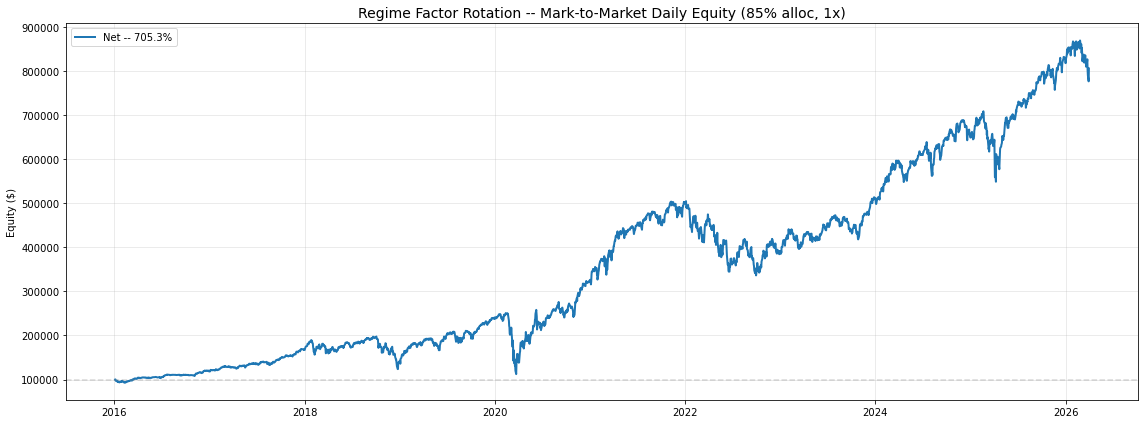

Final equity: $805,316
Total return: 705.3%
Max drawdown: -55.2%

Equal-weight 5-ETF B&H: 241.4% return
  EW Sharpe: 0.74


In [10]:
fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(daily_eq.index.to_numpy(), daily_eq.values, linewidth=2, color="C0",
        label=f"Net -- {(daily_eq.iloc[-1]/STARTING_CAPITAL-1)*100:.1f}%")
ax.axhline(STARTING_CAPITAL, color="gray", linestyle="--", alpha=0.3)
ax.set_title(f"Regime Factor Rotation -- Mark-to-Market Daily Equity ({BET_SIZE:.0%} alloc, {LEVERAGE}x)", fontsize=14)
ax.legend(); ax.grid(True, alpha=0.3); ax.set_ylabel("Equity ($)")
plt.tight_layout(); plt.show()

print(f"Final equity: ${daily_eq.iloc[-1]:,.0f}")
print(f"Total return: {(daily_eq.iloc[-1]/STARTING_CAPITAL-1)*100:.1f}%")
peak = daily_eq.expanding().max()
max_dd = ((daily_eq - peak) / peak).min() * 100
print(f"Max drawdown: {max_dd:.1f}%")

# Quick benchmark: equal-weight 5-ETF buy-and-hold
ew_eq = np.ones(len(daily_eq)) * STARTING_CAPITAL
ret_ew = pd.DataFrame(index=daily_eq.index)
for sym in _syms_traded:
    ret_ew[sym] = _daily_prices[sym].reindex(daily_eq.index).ffill().pct_change()
ew_ret = ret_ew.mean(axis=1).fillna(0)
ew_eq_curve = STARTING_CAPITAL * (1 + ew_ret).cumprod()
print(f"\nEqual-weight 5-ETF B&H: {(ew_eq_curve.iloc[-1]/STARTING_CAPITAL-1)*100:.1f}% return")
ew_sharpe = ew_ret.mean() / ew_ret.std() * np.sqrt(252) if ew_ret.std() > 0 else 0
print(f"  EW Sharpe: {ew_sharpe:.2f}")


BENCHMARK: Does the regime signal earn its keep?
Strategy                               TotRet%    CAGR%   Sharpe   MaxDD%
-------------------------------------------------------------------------------------
Regime Factor Rotation                   705.3    22.60     0.82    -55.2
QUAL B&H (85% exposure)                  214.7    11.85     0.76    -31.0
QUAL+MTUM 50/50 (85% exp)                229.0    12.34     0.76    -31.2
EW 5-ETF B&H (85% exp)                   205.2    11.51     0.74    -33.3

DELTA ANALYSIS vs SIMPLE ALTERNATIVES

vs QUAL B&H:
  Sharpe delta:  +0.06
  Return delta:  +490.6pp
  MaxDD delta:   -24.2pp (positive = shallower)

vs QUAL+MTUM 50/50:
  Sharpe delta:  +0.06
  Return delta:  +476.4pp
  MaxDD delta:   -24.0pp (positive = shallower)


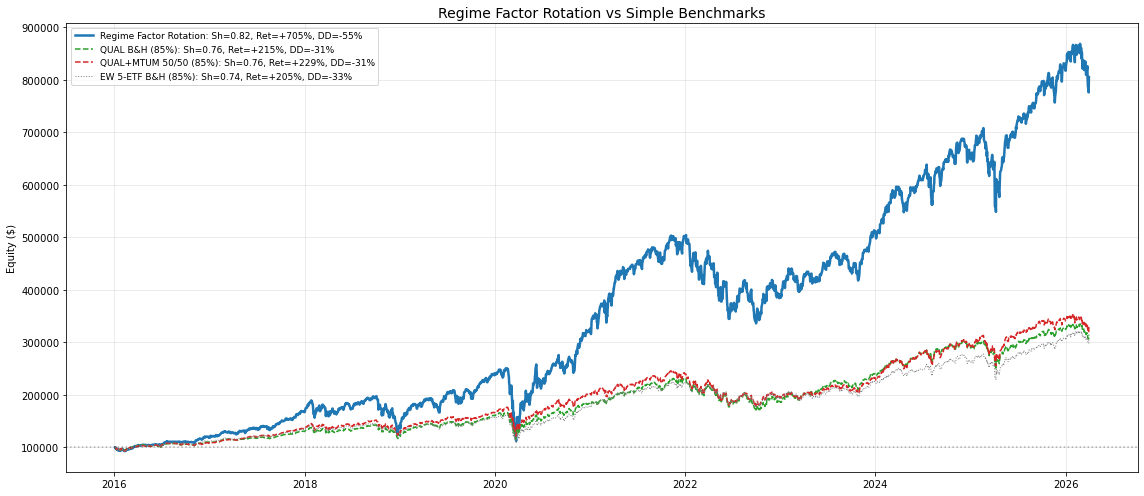


VERDICT

Best simple alternative Sharpe: 0.76
Strategy Sharpe:                0.82
Sharpe gap:                     +0.06

Best simple DD:                 -31.0%
Strategy DD:                    -55.2%
DD gap:                         -24.2pp (negative = deeper)

==> WEAK. Regime signal produces similar risk-adjusted result to QUAL+MTUM.
    You could archive and just hold QUAL+MTUM 50/50 at similar performance.


In [11]:
# =============================================================================
# BENCHMARK: Strategy vs Simple Alternatives
# =============================================================================
# Is the regime signal actually doing work, or could we get the same result
# from just holding QUAL (or QUAL+MTUM 50/50) the whole time?

def _curve_stats(eq, starting=STARTING_CAPITAL):
    ret = eq.pct_change().dropna()
    total = (eq.iloc[-1] / starting - 1) * 100
    sharpe = ret.mean() / ret.std() * np.sqrt(252) if ret.std() > 0 else 0
    peak = eq.expanding().max()
    max_dd = ((eq - peak) / peak).min() * 100
    years = (eq.index[-1] - eq.index[0]).days / 365.25
    cagr = ((eq.iloc[-1]/starting) ** (1/years) - 1) * 100 if years > 0 else 0
    return {"total_return": total, "sharpe": sharpe, "max_dd": max_dd, "cagr": cagr}

# ── Build benchmarks over the same trading window as the strategy ──
bench_start = daily_eq.index.min()
bench_end   = daily_eq.index.max()
bench_dates = pd.bdate_range(bench_start, bench_end)

def _buyhold(sym, dates):
    px = _daily_prices[sym].reindex(dates).ffill()
    # Scale to starting capital
    return STARTING_CAPITAL * px / px.iloc[0]

# 1. QUAL buy-and-hold (BET_SIZE exposure to match strategy's effective exposure)
qual_bh = _buyhold("QUAL", bench_dates)
qual_scaled = STARTING_CAPITAL + (qual_bh - STARTING_CAPITAL) * BET_SIZE  # 85% QUAL, 15% cash

# 2. QUAL + MTUM 50/50 (rebalanced daily for simplicity; close enough)
qual_px = _daily_prices["QUAL"].reindex(bench_dates).ffill()
mtum_px = _daily_prices["MTUM"].reindex(bench_dates).ffill()
qual_ret = qual_px.pct_change().fillna(0)
mtum_ret = mtum_px.pct_change().fillna(0)
combined_ret = 0.5 * qual_ret + 0.5 * mtum_ret  # equal-weight daily
qm_bh = STARTING_CAPITAL * (1 + combined_ret).cumprod()
qm_scaled = STARTING_CAPITAL + (qm_bh - STARTING_CAPITAL) * BET_SIZE  # 85% exposure

# 3. Equal-weight 5-ETF (recompute here to align same dates)
ew_ret_frame = pd.DataFrame(index=bench_dates)
for sym in _syms_traded:
    ew_ret_frame[sym] = _daily_prices[sym].reindex(bench_dates).ffill().pct_change()
ew_ret = ew_ret_frame.mean(axis=1).fillna(0)
ew_bh = STARTING_CAPITAL * (1 + ew_ret).cumprod()
ew_scaled = STARTING_CAPITAL + (ew_bh - STARTING_CAPITAL) * BET_SIZE

# ── Align strategy daily equity to same window ──
strat_eq = daily_eq.reindex(bench_dates).ffill()

# ── Compute stats ──
benchmarks = {
    "Regime Factor Rotation":     _curve_stats(strat_eq),
    "QUAL B&H (85% exposure)":    _curve_stats(qual_scaled),
    "QUAL+MTUM 50/50 (85% exp)":  _curve_stats(qm_scaled),
    "EW 5-ETF B&H (85% exp)":     _curve_stats(ew_scaled),
}

# ── Print comparison ──
print("=" * 85)
print("BENCHMARK: Does the regime signal earn its keep?")
print("=" * 85)
print(f"{'Strategy':<35} {'TotRet%':>10} {'CAGR%':>8} {'Sharpe':>8} {'MaxDD%':>8}")
print("-" * 85)
for name, s in benchmarks.items():
    print(f"{name:<35} {s['total_return']:>10,.1f} {s['cagr']:>8.2f} "
          f"{s['sharpe']:>8.2f} {s['max_dd']:>8.1f}")

# ── Side-by-side stats ──
strat_s = benchmarks["Regime Factor Rotation"]
qual_s  = benchmarks["QUAL B&H (85% exposure)"]
qm_s    = benchmarks["QUAL+MTUM 50/50 (85% exp)"]

print("\n" + "=" * 70)
print("DELTA ANALYSIS vs SIMPLE ALTERNATIVES")
print("=" * 70)
for bench_name, bench_stats in [("QUAL B&H", qual_s), ("QUAL+MTUM 50/50", qm_s)]:
    d_sh  = strat_s["sharpe"]       - bench_stats["sharpe"]
    d_ret = strat_s["total_return"] - bench_stats["total_return"]
    d_dd  = strat_s["max_dd"]       - bench_stats["max_dd"]  # positive = shallower DD
    print(f"\nvs {bench_name}:")
    print(f"  Sharpe delta:  {d_sh:+.2f}")
    print(f"  Return delta:  {d_ret:+,.1f}pp")
    print(f"  MaxDD delta:   {d_dd:+.1f}pp (positive = shallower)")

# ── Plot all curves together ──
fig, ax = plt.subplots(figsize=(16, 7))
curves = {
    "Regime Factor Rotation":       (strat_eq,    "C0", 2.5, "-"),
    "QUAL B&H (85%)":                (qual_scaled, "C2", 1.5, "--"),
    "QUAL+MTUM 50/50 (85%)":        (qm_scaled,   "C3", 1.5, "--"),
    "EW 5-ETF B&H (85%)":           (ew_scaled,   "gray", 1.0, ":"),
}
for name, (eq, color, lw, ls) in curves.items():
    s = _curve_stats(eq)
    ax.plot(eq.index.to_numpy(), eq.values, color=color, linewidth=lw, linestyle=ls,
            label=f"{name}: Sh={s['sharpe']:.2f}, Ret={s['total_return']:+.0f}%, DD={s['max_dd']:.0f}%")
ax.axhline(STARTING_CAPITAL, color="black", linestyle=":", alpha=0.3)
ax.set_title("Regime Factor Rotation vs Simple Benchmarks", fontsize=14)
ax.set_ylabel("Equity ($)"); ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

# ── Verdict ──
print("\n" + "=" * 70)
print("VERDICT")
print("=" * 70)
best_simple_sharpe = max(qual_s["sharpe"], qm_s["sharpe"])
sh_gap = strat_s["sharpe"] - best_simple_sharpe
best_simple_dd = max(qual_s["max_dd"], qm_s["max_dd"])  # max of negatives = shallowest
dd_gap = strat_s["max_dd"] - best_simple_dd

print(f"\nBest simple alternative Sharpe: {best_simple_sharpe:.2f}")
print(f"Strategy Sharpe:                {strat_s['sharpe']:.2f}")
print(f"Sharpe gap:                     {sh_gap:+.2f}")
print(f"\nBest simple DD:                 {best_simple_dd:.1f}%")
print(f"Strategy DD:                    {strat_s['max_dd']:.1f}%")
print(f"DD gap:                         {dd_gap:+.1f}pp (negative = deeper)")

print()
if sh_gap >= 0.15 and dd_gap > -5:
    print("==> KEEP. Regime signal adds meaningful Sharpe without much worse DD.")
elif sh_gap >= 0.10:
    print("==> MARGINAL. Regime signal adds some value; consider with reservation.")
elif sh_gap >= -0.05:
    print("==> WEAK. Regime signal produces similar risk-adjusted result to QUAL+MTUM.")
    print("    You could archive and just hold QUAL+MTUM 50/50 at similar performance.")
else:
    print("==> ARCHIVE. Simpler alternative matches or beats the regime strategy.")

## 7. Per-Factor/ETF Breakdown & Exit Reason Analysis

In [12]:
print(f"{'ETF':<8} {'Factor':<8} {'Trades':>8} {'WR %':>7} {'Avg Ret %':>11} {'Total %':>10} {'Avg Hold':>10}")
print("-" * 75)
for sym in sorted(raw_trades["instrument"].unique()):
    subset = raw_trades[raw_trades["instrument"] == sym]
    if subset.empty:
        continue
    n = len(subset)
    wins = (subset["pct_return_gross"] > 0).sum()
    avg_ret = subset["pct_return_gross"].mean() * 100
    total_ret = ((1 + subset["pct_return_gross"]).prod() - 1) * 100
    avg_hold = (subset["exit_time"] - subset["entry_time"]).dt.days.mean()
    factor = ETF_TO_FACTOR.get(sym, "?")
    print(f"{sym:<8} {factor:<8} {n:>8} {wins/n*100:>6.1f}  {avg_ret:>+10.3f}  {total_ret:>+9.1f}  {avg_hold:>9.1f}d")

print("\n" + "=" * 60)
print("EXIT REASON ANALYSIS")
print("=" * 60)
for reason in raw_trades["exit_reason"].unique():
    subset = raw_trades[raw_trades["exit_reason"] == reason]
    avg_ret = subset["pct_return_gross"].mean() * 100
    avg_hold = (subset["exit_time"] - subset["entry_time"]).dt.days.mean()
    wins = (subset["pct_return_gross"] > 0).sum()
    print(f"  {reason:<15} n={len(subset):3d}, WR={wins/len(subset)*100:.0f}%, "
          f"avg return: {avg_ret:+.2f}%, avg hold: {avg_hold:.0f}d")


ETF      Factor     Trades    WR %   Avg Ret %    Total %   Avg Hold
---------------------------------------------------------------------------
COWZ     CMA            13   92.3      +9.908     +211.0       83.9d
MTUM     Mom             7   85.7     +19.552     +174.8      461.4d
QUAL     RMW             5   80.0     +41.521     +229.4      693.6d
SIZE     SMB             6   83.3      +5.540      +37.4       84.8d
VLUE     HML            13   61.5      +3.068      +18.2      208.2d

EXIT REASON ANALYSIS
  rotation_out    n= 41, WR=78%, avg return: +5.36%, avg hold: 131d
  end_of_data     n=  3, WR=100%, avg return: +108.85%, avg hold: 1874d


## 8. Concurrency & Cohort Analysis

Shows which factors/ETFs tend to be held, how often the cohort rotates, and
whether the regime signal produces concentrated or diversified bets.

ACTIVE-ETF COUNT DISTRIBUTION
  Days active: 2672 / 2672
  Avg ETFs held when active: 2.96
  Median ETFs held when active: 3

ETF HOLDING FREQUENCY (share of active days each ETF was held)
  QUAL   (RMW )  92.9%  ##############################################
  MTUM   (Mom )  86.6%  ###########################################
  VLUE   (HML )  72.6%  ####################################
  COWZ   (CMA )  29.9%  ##############
  SIZE   (SMB )  13.9%  ######

TURNOVER -- ETFs entering/exiting per rebalance cohort
  Avg ETFs entering per rebalance: 1.33
  Avg ETFs exiting per rebalance:  1.33
  Total rebalances with entries:   33


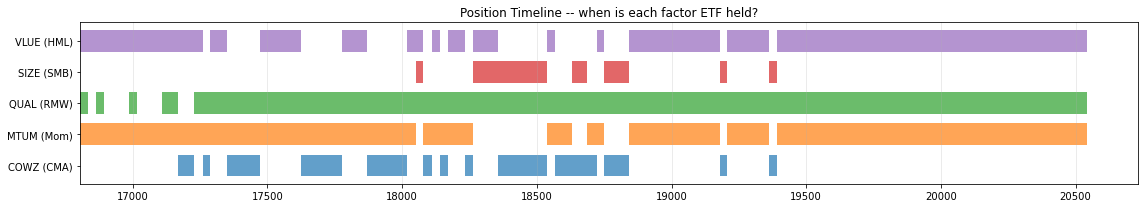

In [13]:
all_dates = pd.date_range(
    raw_trades["entry_time"].min(),
    raw_trades["exit_time"].max(),
    freq="B",
)
syms_traded = sorted(raw_trades["instrument"].unique())
in_pos = pd.DataFrame(0, index=all_dates, columns=syms_traded)

for _, t in raw_trades.iterrows():
    sym = t["instrument"]
    mask = (in_pos.index >= t["entry_time"]) & (in_pos.index <= t["exit_time"])
    in_pos.loc[mask, sym] = 1

print("=" * 70)
print("ACTIVE-ETF COUNT DISTRIBUTION")
print("=" * 70)
active_counts = in_pos.sum(axis=1)
print(f"  Days active: {(active_counts > 0).sum()} / {len(active_counts)}")
print(f"  Avg ETFs held when active: {active_counts[active_counts > 0].mean():.2f}")
print(f"  Median ETFs held when active: {active_counts[active_counts > 0].median():.0f}")

print("\n" + "=" * 70)
print("ETF HOLDING FREQUENCY (share of active days each ETF was held)")
print("=" * 70)
active_days = in_pos.sum(axis=1) > 0
active_slice = in_pos.loc[active_days]
freq = (active_slice.sum(axis=0) / len(active_slice) * 100).sort_values(ascending=False)
for sym, pct in freq.items():
    factor = ETF_TO_FACTOR.get(sym, "?")
    bar = "#" * int(pct / 2)
    print(f"  {sym:<6} ({factor:<4}) {pct:>5.1f}%  {bar}")

print("\n" + "=" * 70)
print("TURNOVER -- ETFs entering/exiting per rebalance cohort")
print("=" * 70)
entries_by_date = raw_trades.groupby(raw_trades["entry_time"].dt.normalize()).size()
exits_by_date   = raw_trades.groupby(raw_trades["exit_time"].dt.normalize()).size()
print(f"  Avg ETFs entering per rebalance: {entries_by_date.mean():.2f}")
print(f"  Avg ETFs exiting per rebalance:  {exits_by_date.mean():.2f}")
print(f"  Total rebalances with entries:   {len(entries_by_date)}")

# Gantt timeline
fig, ax = plt.subplots(figsize=(16, max(3, len(syms_traded) * 0.4)))
for i, sym in enumerate(syms_traded):
    sym_trades = raw_trades[raw_trades["instrument"] == sym]
    for _, t in sym_trades.iterrows():
        ax.barh(i, (t["exit_time"] - t["entry_time"]).days,
                left=t["entry_time"], height=0.7, color=f"C{i % 10}", alpha=0.7)
ax.set_yticks(range(len(syms_traded)))
ax.set_yticklabels([f"{s} ({ETF_TO_FACTOR.get(s,'?')})" for s in syms_traded])
ax.set_title("Position Timeline -- when is each factor ETF held?")
ax.grid(True, alpha=0.3, axis="x")
plt.tight_layout(); plt.show()


## 9. Save Standardized Trades

In [14]:
import os, json

os.makedirs("results", exist_ok=True)

std_cols = ["entry_time", "exit_time", "direction", "instrument",
            "entry_price", "exit_price", "pct_return_gross", "exit_reason", "stop_price"]
raw_trades[std_cols].to_csv(f"results/{SAVE_NAME}_trades.csv", index=False)
print(f"Saved {len(raw_trades)} standardized trades -> results/{SAVE_NAME}_trades.csv")

summary = {
    "strategy":    STRATEGY_NAME,
    "instruments": ETFS,
    "factor_map":  FACTOR_TO_ETF,
    "portfolio":   "long_term",
    "trade_period": f"{TRADE_START} -> {TRADE_END}",
    "macro_training_start": MACRO_START,
    "params":      {k: v for k, v in DEFAULT_PARAMS.items()},
    "gmm_params":  {"pca": GMM_PCA_COMPONENTS, "cov": GMM_COV_TYPE,
                    "refit_every": GMM_REFIT_EVERY, "init_train_pct": GMM_INIT_TRAIN_PCT},
    "trades":      len(raw_trades),
    "has_stop":    False,
    "architecture": "basket",
    "significance": {
        "gross": {"sharpe": report_gross["bootstrap"]["observed_sharpe"],
                  "verdict": report_gross["verdict"],
                  "tests_passed": report_gross["tests_passed"]},
        "net":   {"sharpe": report_net["bootstrap"]["observed_sharpe"],
                  "verdict": report_net["verdict"],
                  "tests_passed": report_net["tests_passed"]},
    },
}
with open(f"results/{SAVE_NAME}_summary.json", "w") as f:
    json.dump(summary, f, indent=2, default=str)
print(f"Saved summary -> results/{SAVE_NAME}_summary.json")
print(f"\nNext: run Regime_Factor_Rotation_Implementation.ipynb for sizing comparison")


Saved 44 standardized trades -> results/regime_factor_rotation_trades.csv
Saved summary -> results/regime_factor_rotation_summary.json

Next: run Regime_Factor_Rotation_Implementation.ipynb for sizing comparison
